In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import seaborn as sns
import seaborn.objects as so
from dataretrieval import nwis
from rasterio.crs import CRS
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf
from statsmodels.stats import anova

import os

In [7]:
def cumulative_exceedence_pct(val: np.float64, series: pd.Series) -> np.float64:
  m = series > val
  return np.float64(len(series[m])/len(series))

def calc_relative_frequency(x: np.float64, vals: np.ndarray) -> np.float64:
    rank = vals <= x
    return np.float64(len(vals[rank])/(len(vals) + 1))

In [8]:
# from Prof Allan Frei
watersheds_shp_fp = os.path.relpath("../datasets/watershed_bounds/basin24/basin24.shp")

watershed_stream_gages_fp = os.path.relpath("../datasets/stream_gages/watershed_stream_gages.geojson")
watersheds_impermeability_fp = os.path.relpath("../datasets/out/watersheds_impermeability.geojson")
stream_gage_fp = os.path.relpath("../datasets/stream_gages/realstx_shp/realstx.shp")
site_watersheds_fp = os.path.relpath("../datasets/out/stream_gage_watersheds_impermeability.geojson")

capacity_fp = os.path.relpath("../datasets/reservoirs/reservoir_lvls.csv")
yearly_water_consumption_fp = os.path.relpath("../datasets/water_use/yearly_water_consumption.csv")

In [9]:
# helpful variables
esopus_coldbrook_site = "01362500"
delaware_walton_site = "01423000"
e_croton_putnam_site = "0137449480"
w_croton_richardsville_site = "01374559"
# sites upstream of reservoirs
upstream_site_ids = [
  "0142400103", # trout creek
  delaware_walton_site,
  "01422779", # West Brook Walton
  "01422747", # East Brook Walton
  "01421900", # West Branch Delaware Delhi, NY
  "01422500", # Little Delaware Delhi
  "01421610", # West Branch Delaware Hobart
  "01421618", # Town Brook Hobart
  "01350080", # Manor Kill Gilboa
  "01350035", # Bear Kill Prattsville
  "01349950", # Batavia Kill at Red Falls
  "01413500", # East Branch Delaware Margaretville
  "01414000", # Plattekill Dunraven
  "01365000", # Rondout Creek Lowes Corners
  "01365550", # Chestnut Creek Grahamsville
  "01363382", # Bush Kill West Shokan
  "01362200", # Esopus Creek at Allaben
  
  w_croton_richardsville_site,
  e_croton_putnam_site,
  "01374598", # Horse Pound Brook Carmel
  "01374781", # Titicus River Salem Center
  "01374890", # Cross River
]

# see https://help.waterdata.usgs.gov/code/parameter_cd_query?fmt=rdb&group_cd=PHY&inline=true
discharge_param_code = "00060" # ft3/s
peak_discharge_param_code = "62856" #ft3/s
# see https://help.waterdata.usgs.gov/stat_code
max_stat_code = "00001"
mean_stat_code = "00003"

cubic_ft_cumec_const = 0.0283168

In [10]:
grid_color = "#00FC22"
pink = "#FF27FC"
blue = "#08FCFD"
orange = "#FF2B18"
sns.set_style(rc={
    "figure.facecolor": "black",
    "font.family": "monospace",
    "font.weight": 900,
    "axes.facecolor": "black",
    "axes.grid": True,
    "axes.labelcolor": "white",
    "text.color": "white",
    "axes.spines.right": True,
    "axes.spines.top": True,
    "grid.color": grid_color,
    "grid.linestyle": "dotted",
    "grid.linewidth": 0.5,
    "xtick.color": "white",
    "ytick.color": "white",
})
sns.set_palette([
  pink, blue, orange
])

In [11]:
yearly_consumption_df = pd.read_csv(yearly_water_consumption_fp)
yearly_consumption_df.loc[yearly_consumption_df["Per Capita(Gallons per person per day)"].isna(), "Per Capita(Gallons per person per day)"] = yearly_consumption_df.loc[yearly_consumption_df["Per Capita(Gallons per person per day)"].isna(), "NYC Consumption(Million gallons per day)"] * 1000000 / yearly_consumption_df.loc[yearly_consumption_df["Per Capita(Gallons per person per day)"].isna(), "New York City Population"]


In [12]:
yearly_consumption_df

,Year,New York City Population,NYC Consumption(Million gallons per day),Per Capita(Gallons per person per day)
0,1960,7781984,1199.4,154.125221
1,1961,7793342,1221.0,156.672195
2,1962,7804700,1207.6,154.727280
3,1963,7816058,1217.4,155.756265
4,1964,7827416,1189.2,151.927533
...,...,...,...,...
60,2020,8804190,981.0,111.420000
61,2021,8454000,979.0,115.800000
62,2022,8356000,999.0,119.550000
63,2023,8391000,997.0,118.820000


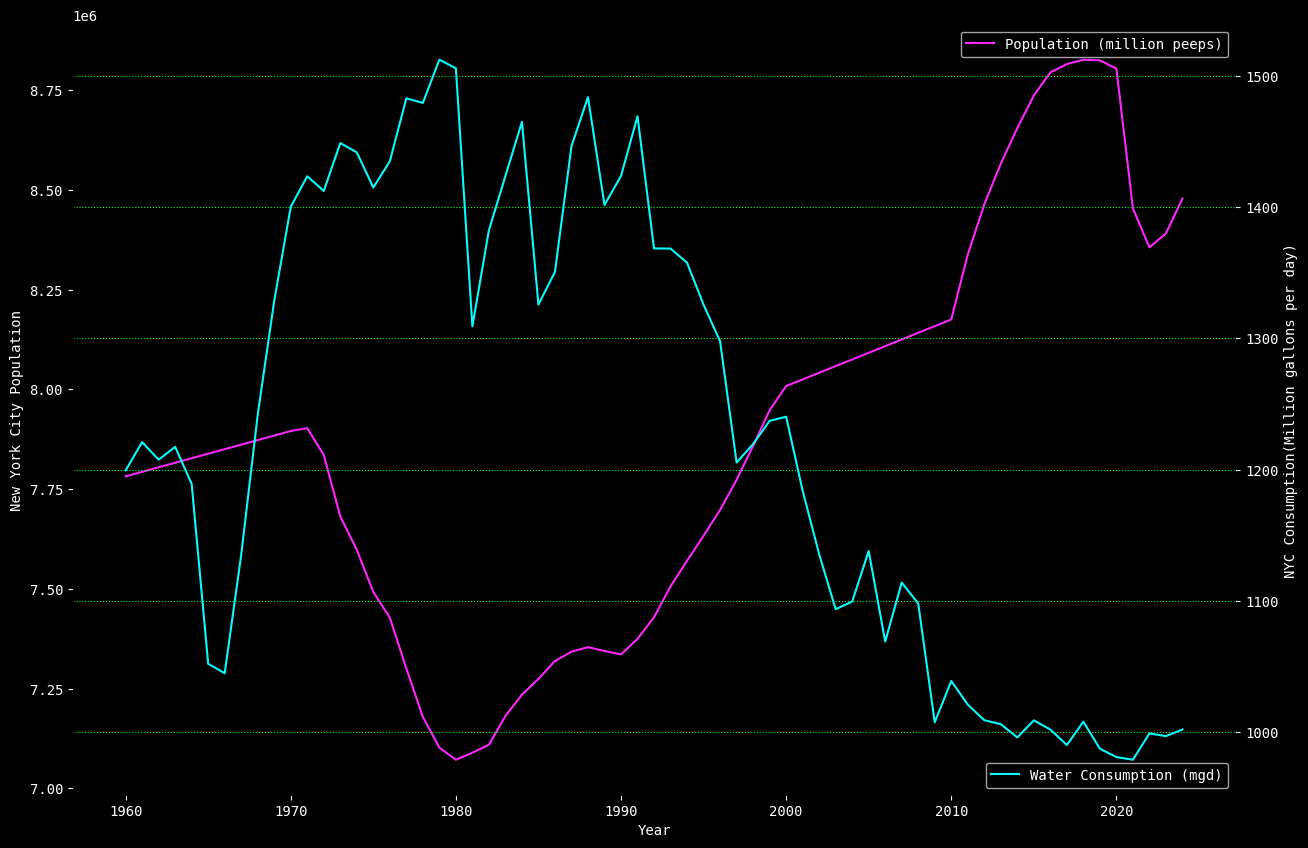

In [13]:
fig, ax = plt.subplots(figsize=(15, 10))
g = sns.lineplot(data=yearly_consumption_df, x="Year", y="New York City Population", ax=ax)
g.grid(False)
g.legend(["Population (million peeps)"])
ax2 = g.twinx()
g2 = sns.lineplot(data=yearly_consumption_df, x="Year", y="NYC Consumption(Million gallons per day)", ax=ax2, color=blue)
g2.legend(["Water Consumption (mgd)"])
sns.move_legend(g2, "lower right")

In [14]:
watersheds_gdf = gpd.read_file(watersheds_shp_fp)
stream_gage_gdf = gpd.read_file(watershed_stream_gages_fp)
# we have the stream gages in the watershed, now we want the specific watershed for each
# stream gage. See `download_nldi_data.ipynb` and `watersheds.ipynb` for processing
site_watershed_raw_gdf = gpd.read_file(site_watersheds_fp).set_index("site_no")
# the above is split by year to allow for finer-grained analysis if wanted, but we really only care about the aggregate/mean stats on a watershed
site_watershed_gdf = site_watershed_raw_gdf.groupby(by="site_no").agg({
  "basin_name": "first",
  "area_sq_miles": "first",
  "BASIN": "first",
  "watershed_area": "first",
  "geometry": "first",
  "impervious_fraction": "mean",
  "barren": "mean",
  "deciduous": "mean",
  "evergreen": "mean",
  "mixed_forest": "mean",
  "shrub": "mean",
  "grasslands": "mean",
  "pasture": "mean",
  "cultivated": "mean",
  "wetlands": "mean",
})

site_watershed_gdf["relative_location"] = "downstream"
site_watershed_gdf.loc[upstream_site_ids, "relative_location"] = "upstream"

watersheds_gdf = watersheds_gdf.to_crs(stream_gage_gdf.crs if stream_gage_gdf.crs != None else CRS.from_epsg(4326))

watersheds_gdf.explore()

In [15]:
site_watershed_gdf

,basin_name,area_sq_miles,BASIN,watershed_area,geometry,impervious_fraction,barren,deciduous,evergreen,mixed_forest,shrub,grasslands,pasture,cultivated,wetlands,relative_location
site_no,,,,,,,,,,,,,,,,
01349700,Schoharie 01349700,36.245518,Schoharie,catskill_delaware_outer,"POLYGON ((-74.09025 42.25915, -74.08524 42.258...",0.008899,0.000444,0.541706,0.068191,0.259565,0.000927,0.0,0.043463,0.001992,0.027283,downstream
01349705,Schoharie 01349705,101.781469,Schoharie,catskill_delaware_outer,"POLYGON ((-74.12597 42.11956, -74.12776 42.124...",0.008899,0.001540,0.491027,0.093967,0.275782,0.001629,0.0,0.037955,0.000709,0.029428,downstream
01349711,Schoharie 01349711,31.397185,Schoharie,catskill_delaware_outer,"POLYGON ((-74.37291 42.17581, -74.38095 42.181...",0.008899,0.000058,0.698525,0.064135,0.168883,0.000183,0.0,0.034616,0.000000,0.004906,downstream
01349810,Schoharie 01349810,31.397185,Schoharie,catskill_delaware_outer,"POLYGON ((-74.37291 42.17581, -74.38095 42.181...",0.008899,0.000058,0.698525,0.064135,0.168883,0.000183,0.0,0.034616,0.000000,0.004906,downstream
01349950,Schoharie 01349950,73.186323,Schoharie,catskill_delaware_outer,"POLYGON ((-74.27005 42.36762, -74.2664 42.3739...",0.008899,0.000919,0.469981,0.086772,0.251850,0.001768,0.0,0.084271,0.001145,0.025705,upstream
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
01434021,Neversink 01434021,3.360270,Neversink,catskill_delaware_outer,"POLYGON ((-74.43419 41.99186, -74.44274 41.998...",0.002958,0.000000,0.740195,0.125462,0.121367,0.000222,0.0,0.000000,0.000000,0.001550,downstream
01434025,Neversink 01434025,3.841236,Neversink,catskill_delaware_outer,"POLYGON ((-74.48846 41.99703, -74.50007 41.992...",0.002958,0.000000,0.981433,0.002894,0.015646,0.000000,0.0,0.000000,0.000000,0.000000,downstream
01434498,Neversink 01434498,34.416063,Neversink,catskill_delaware_outer,"POLYGON ((-74.43419 41.99186, -74.43579 41.989...",0.002958,0.000026,0.887958,0.018205,0.066215,0.001448,0.0,0.002681,0.000000,0.006220,downstream


<Axes: xlabel='wetlands', ylabel='area_sq_miles'>

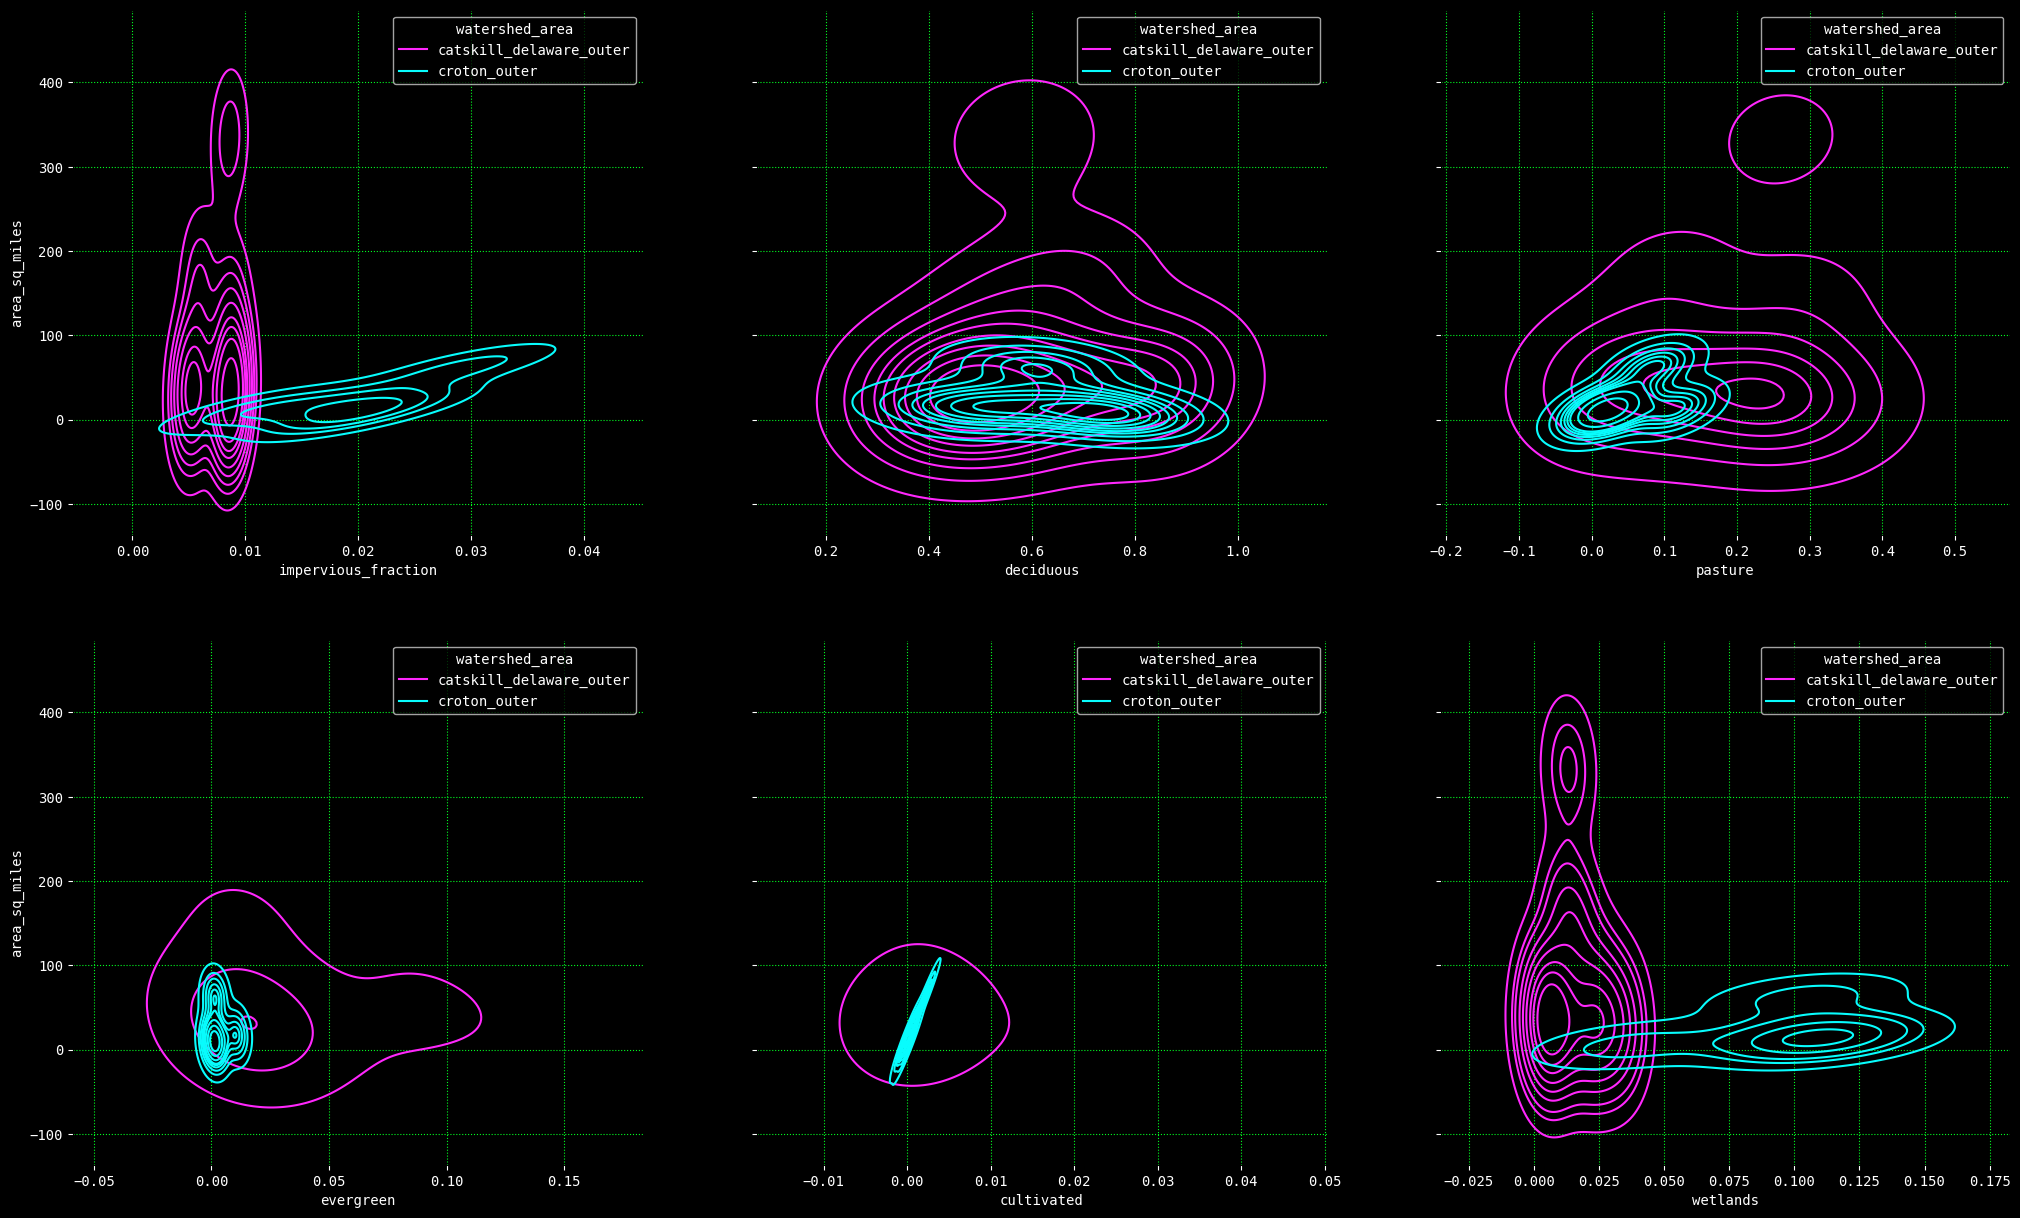

In [16]:
fig, ax = plt.subplots(2,3, figsize=(25,15), sharey=True, )
sns.kdeplot(data=site_watershed_gdf.loc[upstream_site_ids], y="area_sq_miles", x="impervious_fraction", hue="watershed_area", ax=ax[0,0])
sns.kdeplot(data=site_watershed_gdf.loc[upstream_site_ids], y="area_sq_miles", x="deciduous", hue="watershed_area", ax=ax[0,1])
sns.kdeplot(data=site_watershed_gdf.loc[upstream_site_ids], y="area_sq_miles", x="pasture", hue="watershed_area", ax=ax[0,2])
sns.kdeplot(data=site_watershed_gdf.loc[upstream_site_ids], y="area_sq_miles", x="evergreen", hue="watershed_area", ax=ax[1,0])
sns.kdeplot(data=site_watershed_gdf.loc[upstream_site_ids], y="area_sq_miles", x="cultivated", hue="watershed_area", ax=ax[1,1])
sns.kdeplot(data=site_watershed_gdf.loc[upstream_site_ids], y="area_sq_miles", x="wetlands", hue="watershed_area", ax=ax[1,2])
# sns.scatterplot(data=site_watershed_gdf, y="area_sq_miles", x="impervious_fraction", hue="watershed_area", style="watershed_area", ax=ax[0,0], markers=["x", "+"], edgecolor=None, s=49)
# sns.scatterplot(data=site_watershed_gdf, y="area_sq_miles", x="deciduous", hue="watershed_area", style="watershed_area", ax=ax[0,1], markers=["x", "+"], edgecolor=None, s=49)
# sns.scatterplot(data=site_watershed_gdf, y="area_sq_miles", x="pasture", hue="watershed_area", style="watershed_area", ax=ax[0,2], markers=["x", "+"], edgecolor=None, s=49)
# sns.scatterplot(data=site_watershed_gdf, y="area_sq_miles", x="evergreen", hue="watershed_area", style="watershed_area", ax=ax[1,0], markers=["x", "+"], edgecolor=None, s=49)
# sns.scatterplot(data=site_watershed_gdf, y="area_sq_miles", x="cultivated", hue="watershed_area", style="watershed_area", ax=ax[1,1], markers=["x", "+"], edgecolor=None, s=49)
# sns.scatterplot(data=site_watershed_gdf, y="area_sq_miles", x="wetlands", hue="watershed_area", style="watershed_area", ax=ax[1,2], markers=["x", "+"], edgecolor=None, s=49)
# sns.kdeplot(data=site_watershed_gdf, x="area_sq_miles", y="impervious_fraction", hue="watershed_area", ax=ax[0,0])
# sns.pairplot(data=site_watershed_gdf, y_vars=["area_sq_miles"], x_vars=["impervious_fraction", "deciduous", "pasture", "evergreen", "cultivated", "wetlands"], hue="watershed_area", markers="x")

## Get values from USGS NWIS

Given the stream gage ids within the NYC reservoir watershed, pull data from USGS's water APIs (via their `dataretrieval` tool).

- `nwis.get_dv` pulls all daily values from stream gages requested. For us, we only care about daily mean discharge
- `nwis.get_discharge_peaks` pulls yearly peaks from sites (stream gages) requested. NOTE: the "water year" starts in October

In [17]:
site_ids = list(stream_gage_gdf["site_no"].unique())

## Using Daily Values

Given daily mean flow data, we can get a sense for how different streams in the watershed behave. Again, we can use essentially the cumulative distribution to make a flow duration curve, which can give a sense for how a stream behaves (high-highs and low-lows, vs steady flow). We can also get a better look at seasonality.

In [18]:
parameter_codes = [discharge_param_code, peak_discharge_param_code]
stat_codes = [mean_stat_code, max_stat_code] # this actually isn't needed
raw_measurements_df, meta = nwis.get_dv(sites=site_ids, parameterCd=parameter_codes, start="1930-10-01", statCd=stat_codes)

In [19]:
# clean/remove invalid vals
m = raw_measurements_df["00060_Mean"] >= 0
stream_gage_measurements = pd.concat([raw_measurements_df[m], raw_measurements_df.index.to_frame()], axis=1).dropna()
stream_gage_measurements = stream_gage_measurements.rename({"site_no": "site_number"}, axis=1)

# convert to m3/s (aka) cumec
stream_gage_measurements["mean_cumec"] = stream_gage_measurements["00060_Mean"] * cubic_ft_cumec_const
# the average flow (cumecs) of the site over the entire record
stream_gage_measurements["overall_mean_flow"] = stream_gage_measurements.groupby(by="site_number")["mean_cumec"].transform("mean")

# add useful date cols
stream_gage_measurements["year"] = stream_gage_measurements["datetime"].dt.year
stream_gage_measurements["month"] = stream_gage_measurements["datetime"].dt.month
stream_gage_measurements["day_of_year"] = stream_gage_measurements["datetime"].dt.day_of_year
stream_gages_watersheds = pd.merge(left=stream_gage_measurements, right=site_watershed_gdf, left_on="site_number", right_on="site_no", how="left")
stream_gages_watersheds

,00060_Mean,00060_Mean_cd,site_number,datetime,mean_cumec,overall_mean_flow,year,month,day_of_year,basin_name,...,barren,deciduous,evergreen,mixed_forest,shrub,grasslands,pasture,cultivated,wetlands,relative_location
0,119.0,A,01349700,1996-12-27 00:00:00+00:00,3.369699,2.296126,1996,12,362,Schoharie 01349700,...,0.000444,0.541706,0.068191,0.259565,0.000927,0.0,0.043463,0.001992,0.027283,downstream
1,103.0,A,01349700,1996-12-28 00:00:00+00:00,2.916630,2.296126,1996,12,363,Schoharie 01349700,...,0.000444,0.541706,0.068191,0.259565,0.000927,0.0,0.043463,0.001992,0.027283,downstream
2,143.0,A,01349700,1996-12-29 00:00:00+00:00,4.049302,2.296126,1996,12,364,Schoharie 01349700,...,0.000444,0.541706,0.068191,0.259565,0.000927,0.0,0.043463,0.001992,0.027283,downstream
3,185.0,A,01349700,1996-12-30 00:00:00+00:00,5.238608,2.296126,1996,12,365,Schoharie 01349700,...,0.000444,0.541706,0.068191,0.259565,0.000927,0.0,0.043463,0.001992,0.027283,downstream
4,123.0,A,01349700,1996-12-31 00:00:00+00:00,3.482966,2.296126,1996,12,366,Schoharie 01349700,...,0.000444,0.541706,0.068191,0.259565,0.000927,0.0,0.043463,0.001992,0.027283,downstream
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
831179,56.6,P,01435000,2025-08-13 00:00:00+00:00,1.602731,5.635950,2025,8,225,Neversink 01435000,...,0.000272,0.768145,0.050587,0.145857,0.000973,0.0,0.006657,0.000000,0.007229,downstream
831180,56.8,P,01435000,2025-08-14 00:00:00+00:00,1.608394,5.635950,2025,8,226,Neversink 01435000,...,0.000272,0.768145,0.050587,0.145857,0.000973,0.0,0.006657,0.000000,0.007229,downstream
831181,53.6,P,01435000,2025-08-15 00:00:00+00:00,1.517780,5.635950,2025,8,227,Neversink 01435000,...,0.000272,0.768145,0.050587,0.145857,0.000973,0.0,0.006657,0.000000,0.007229,downstream
831182,52.1,P,01435000,2025-08-16 00:00:00+00:00,1.475305,5.635950,2025,8,228,Neversink 01435000,...,0.000272,0.768145,0.050587,0.145857,0.000973,0.0,0.006657,0.000000,0.007229,downstream


Text(0.5, 1.0, 'ECDF Plot of Discharge in Watersheds')

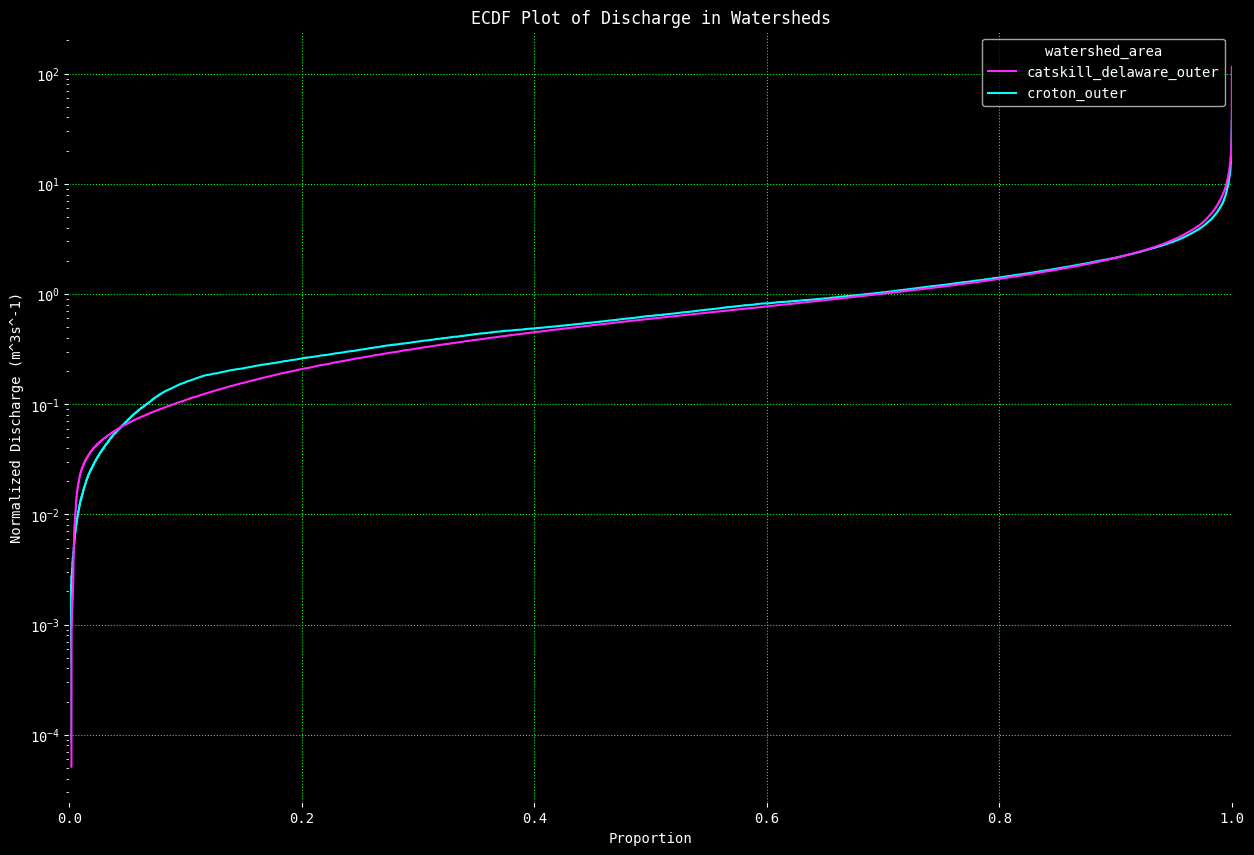

In [68]:
g = sns.ecdfplot(data=stream_gages_watersheds, y=(stream_gages_watersheds["mean_cumec"]/stream_gages_watersheds["overall_mean_flow"]), hue="watershed_area", log_scale=True)
g.figure.set_size_inches(15,10)
g.axes.set_ylabel("Normalized Discharge (m^3s^-1)")
g.set_title("ECDF Plot of Discharge in Watersheds")

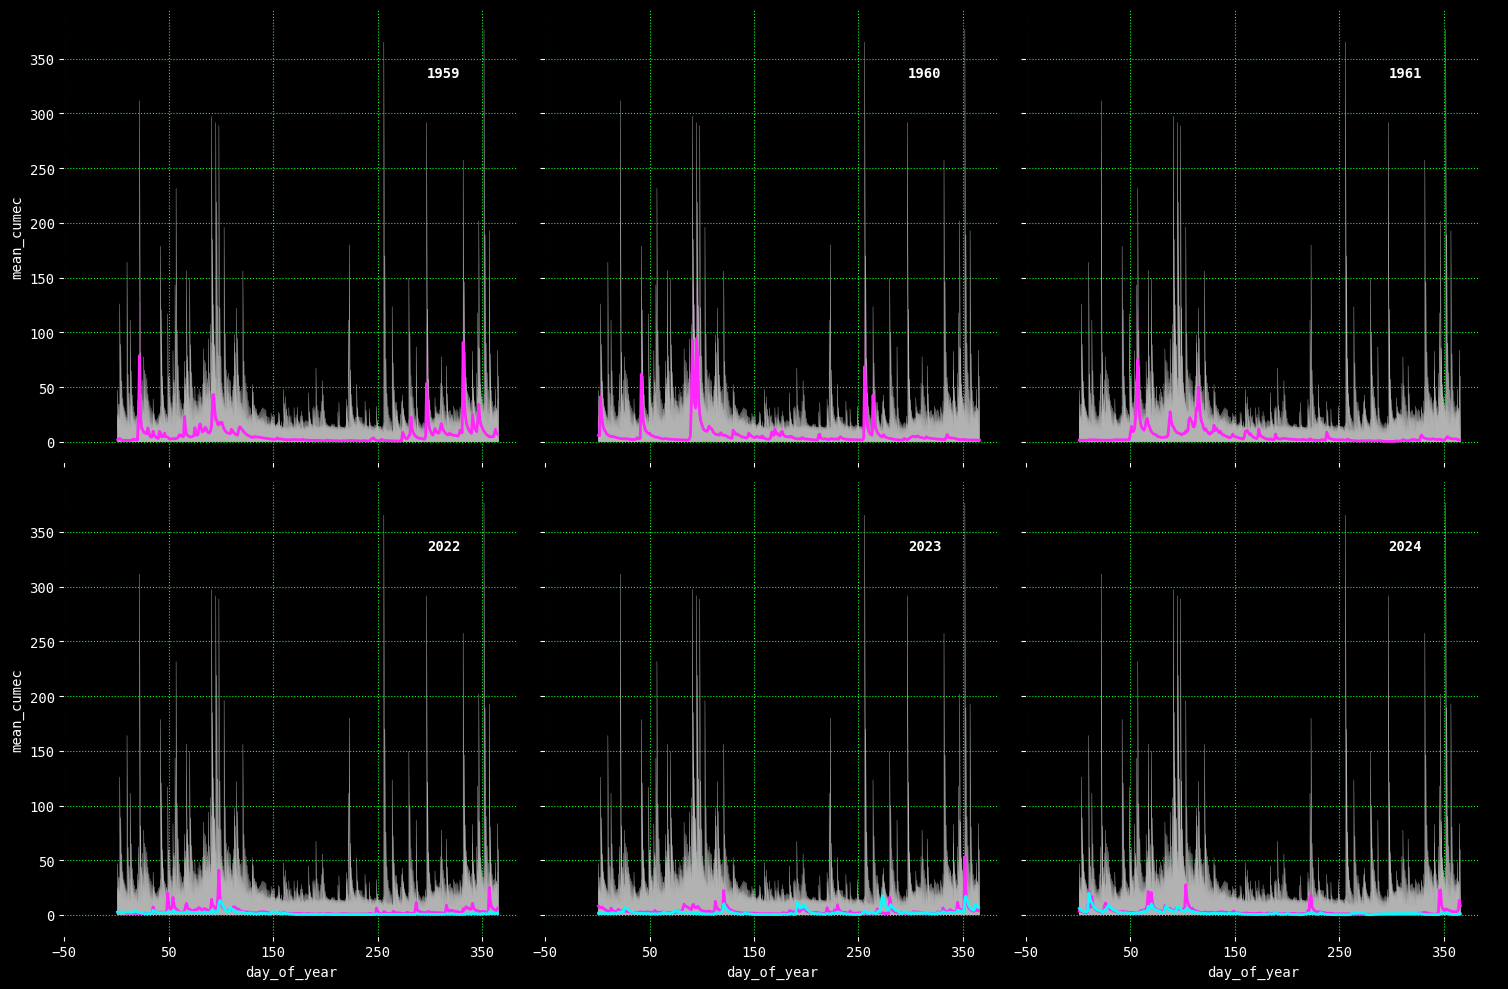

In [76]:
g = sns.relplot(data=stream_gages_watersheds[stream_gages_watersheds["year"].isin([1959,1960,1961,2022,2023,2024])], x="day_of_year", y="mean_cumec", col="year", hue="watershed_area", kind="line", col_wrap=3, legend=False, zorder=5, linewidth=2)
for year, ax in g.axes_dict.items():

    # Add the title as an annotation within the plot
    ax.text(.8, .85, year, transform=ax.transAxes, fontweight="bold")

    # Plot every year's time series in the background
    sns.lineplot(
        data=stream_gages_watersheds[stream_gages_watersheds["year"].isin([1959,1960,1961,2022,2023,2024])], x="day_of_year", y="mean_cumec", units="year",
        estimator=None, color=".7", linewidth=0.3, ax=ax,
    )

# Reduce the frequency of the x axis ticks
ax.set_xticks(ax.get_xticks()[::2])
g.set_titles("")
g.tight_layout()
g.add_legend()

Text(0.5, 1.0, 'Average Flow by Day of Year')

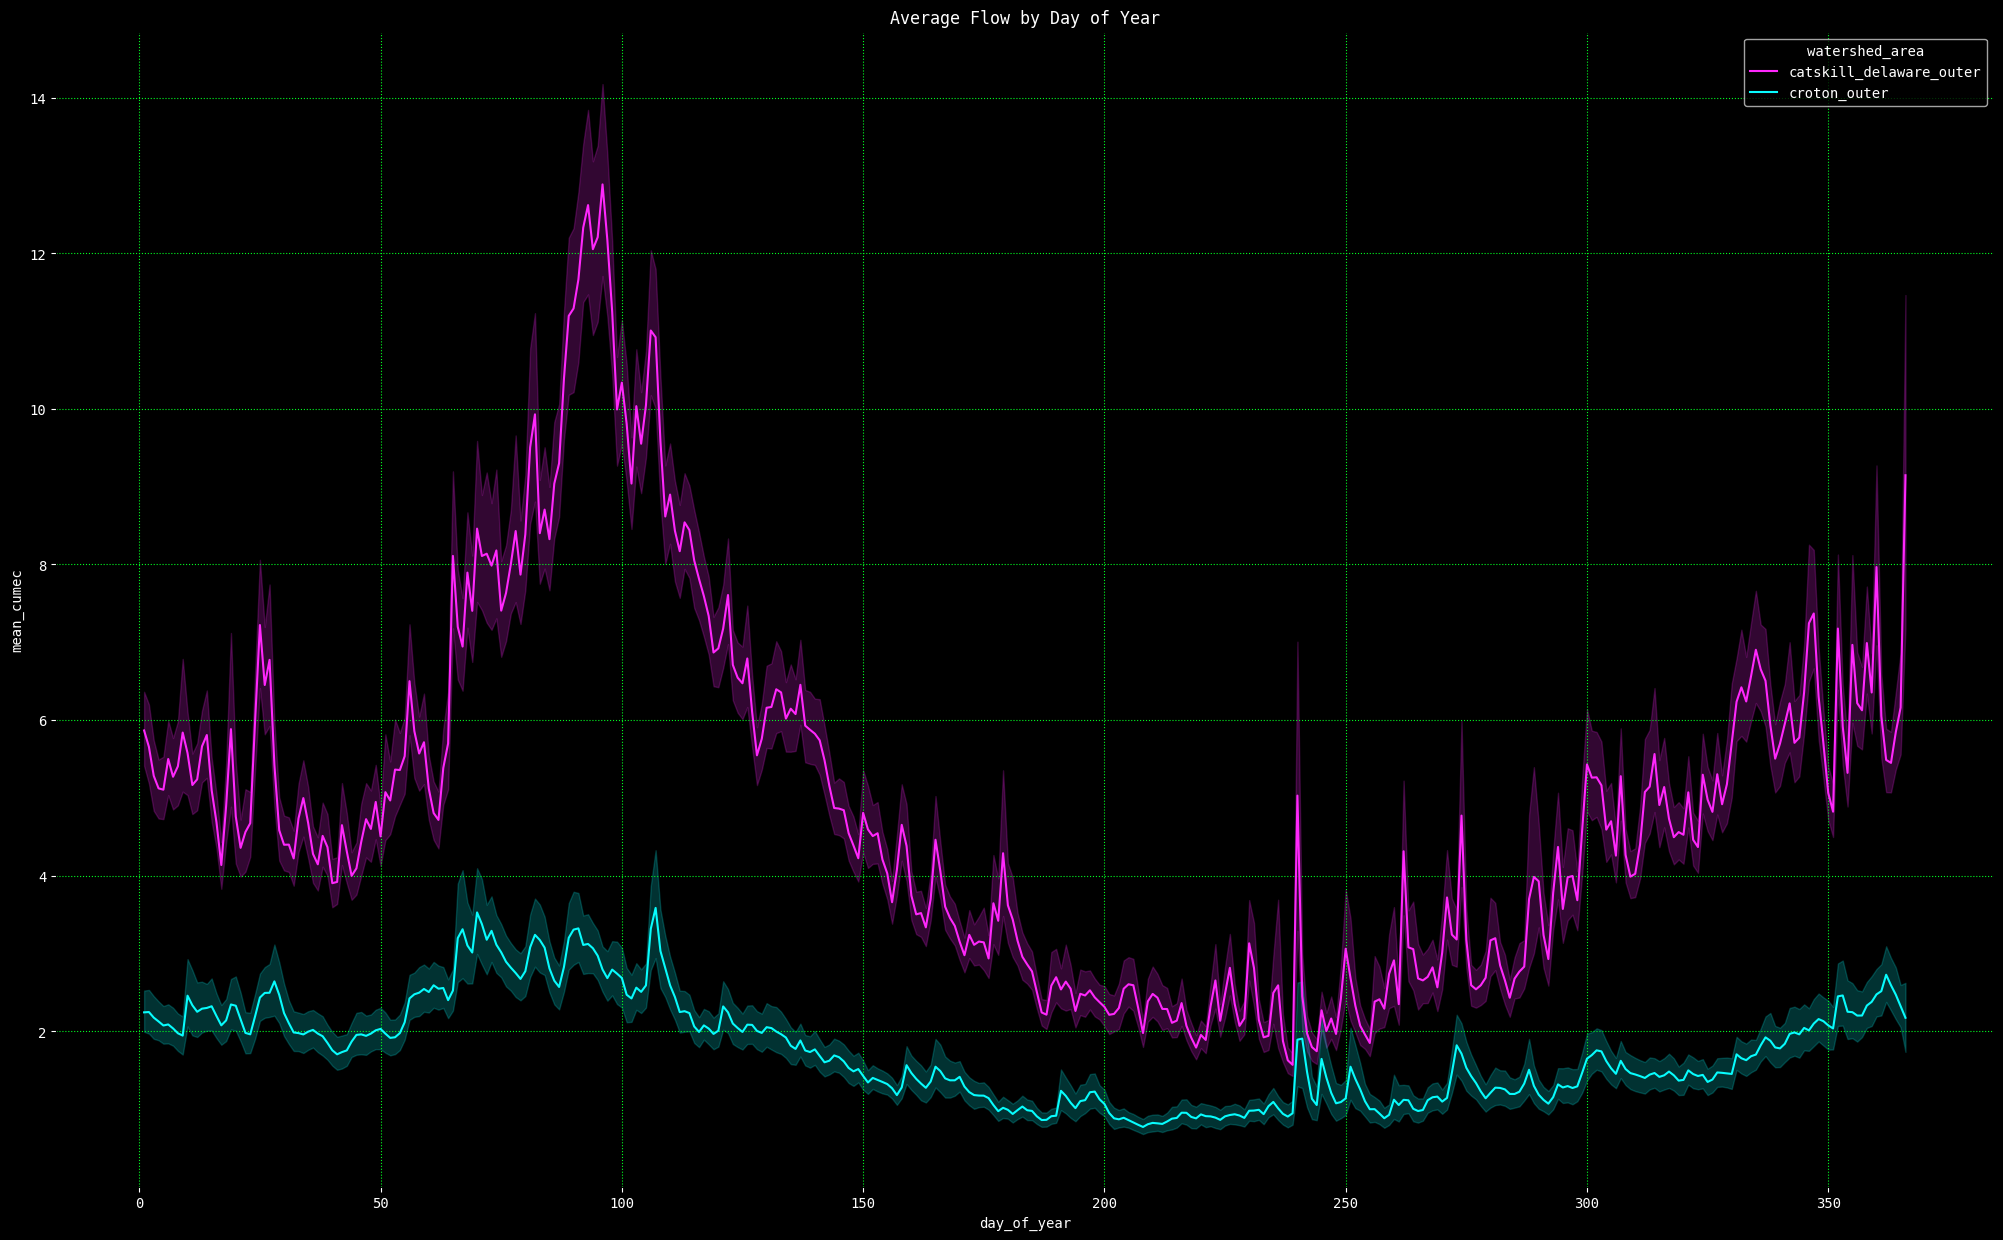

In [75]:
g = sns.lineplot(data=stream_gages_watersheds, x="day_of_year", y="mean_cumec", hue="watershed_area")
g.figure.set_size_inches(25,15)
g.set_title("Average Flow by Day of Year")

### Using Peak Values

Peak values are generally used to understand year-over-year flooding or drought behavior in a watershed. This is because YoY peak levels are considered "independent", even though multi-year and even decadal oscillations in seasonal stream behavior have been observed

In [23]:
peaks_df, meta = nwis.get_discharge_peaks(sites=site_ids, start="1930-10-01")
sites, meta = meta.site_info
# drop rows with missing `peak_va`. Not many!
peaks_df = peaks_df.dropna(subset="peak_va")

In [24]:
# fit a regression model to our data with year as the independent var, and peak flow as dependent
# this essentially accounts for any trend over time, and eliminates change over time as a factor
# what we're trying to compare between watersheds is variance in peak flows.

# add year col for convenience
peaks_df.loc[:,"year"] = peaks_df.index.get_level_values("datetime").year

for site_id in peaks_df.index.get_level_values("site_no"):
  if peaks_df.loc[(site_id)].shape[0] < 3:
    # for some reason the regression doesn't like this
    continue
  mod = smf.ols("peak_va ~ year", data=peaks_df.loc[(site_id)])
  res = mod.fit()
  # now, we want to get the residuals from our model, essentially the distance from
  # the trend line
  peaks_df.loc[(site_id), "residual"] = res.resid.values
  pred = res.get_prediction()
  peaks_df.loc[(site_id), "predicted_mean"] = pred.predicted_mean
  
  # print(res.summary())

peaks_df.loc[:, "normalized_residual"] = peaks_df.loc[:, "residual"] / peaks_df.loc[:, "predicted_mean"]


In [25]:
for site_id in peaks_df.index.get_level_values("site_no"):
  if peaks_df.loc[(site_id)].shape[0] < 3:
    # for some reason the regression doesn't like this
    continue
  mod = smf.ols("peak_va ~ year", data=peaks_df.loc[(site_id)])
  res = mod.fit()
  # now, we want to get the residuals from our model, essentially the distance from
  # the trend line
  peaks_df.loc[(site_id), "residual"] = res.resid.values
  pred = res.get_prediction()
  peaks_df.loc[(site_id), "predicted_mean"] = pred.predicted_mean
  
  # print(res.summary())

peaks_df.loc[:, "normalized_residual"] = peaks_df.loc[:, "residual"] / peaks_df.loc[:, "predicted_mean"]


In [26]:
peaks_df

agency_cd peak_tm  peak_va peak_cd  \
site_no  datetime                                                       
01349700 1951-03-31 00:00:00+00:00      USGS     NaN   6450.0       7   
         1955-10-16 00:00:00+00:00      USGS     NaN   9920.0       7   
         1960-09-12 00:00:00+00:00      USGS     NaN   7900.0     2,7   
         1965-08-14 00:00:00+00:00      USGS     NaN    860.0       2   
         1966-03-25 00:00:00+00:00      USGS     NaN   1500.0       2   
...                                      ...     ...      ...     ...   
01435000 2019-11-01 00:00:00+00:00      USGS   01:15   8530.0     NaN   
         2020-12-25 00:00:00+00:00      USGS   05:45   9100.0     NaN   
         2021-10-26 00:00:00+00:00      USGS   14:20   9170.0     NaN   
         2022-12-07 00:00:00+00:00      USGS   03:50   4000.0     NaN   
         2023-12-18 00:00:00+00:00      USGS   07:37   7020.0     NaN   

                                    gage_ht gage_ht_cd  year_last_pk  \
site_no  datetime                                                      
01349700 1951-03-31 00:00:00+00:00     8.92          3           NaN   
         1955-10-16 00:00:00+00:00    11.10          3           NaN   
         1960-09-12 00:00:00+00:00      NaN        NaN           NaN   
         1965-08-14 00:00:00+00:00     3.40          3           NaN   
         1966-03-25 00:00:00+00:00      NaN        NaN           NaN   
...                                     ...        ...           ...   
01435000 2019-11-01 00:00:00+00:00    11.48        NaN           NaN   
         2020-12-25 00:00:00+00:00    11.65          2           NaN   
         2021-10-26 00:00:00+00:00    11.68        NaN           NaN   
         2022-12-07 00:00:00+00:00     9.74        NaN           NaN   
         2023-12-18 00:00:00+00:00    11.47        NaN           NaN   

                                         ag_dt  ag_tm  ag_gage_ht  \
site_no  datetime                                                   
01349700 1951-03-31 00:00:00+00:00         NaN    NaN         NaN   
         1955-10-16 00:00:00+00:00         NaN    NaN         NaN   
         1960-09-12 00:00:00+00:00         NaN    NaN         NaN   
         1965-08-14 00:00:00+00:00         NaN    NaN         NaN   
         1966-03-25 00:00:00+00:00         NaN    NaN         NaN   
...                                        ...    ...         ...   
01435000 2019-11-01 00:00:00+00:00         NaN    NaN         NaN   
         2020-12-25 00:00:00+00:00  2020-12-25  407.0       12.34   
         2021-10-26 00:00:00+00:00         NaN    NaN         NaN   
         2022-12-07 00:00:00+00:00         NaN    NaN         NaN   
         2023-12-18 00:00:00+00:00         NaN    NaN         NaN   

                                   ag_gage_ht_cd  year     residual  \
site_no  datetime                                                     
01349700 1951-03-31 00:00:00+00:00           NaN  1951  -477.777804   
         1955-10-16 00:00:00+00:00           NaN  1955  3126.374644   
         1960-09-12 00:00:00+00:00           NaN  1960  1274.065203   
         1965-08-14 00:00:00+00:00           NaN  1965 -5598.244238   
         1966-03-25 00:00:00+00:00           NaN  1966 -4924.706126   
...                                          ...   ...          ...   
01435000 2019-11-01 00:00:00+00:00           NaN  2019   887.360279   
         2020-12-25 00:00:00+00:00             1  2020  1444.537304   
         2021-10-26 00:00:00+00:00           NaN  2021  1501.714328   
         2022-12-07 00:00:00+00:00           NaN  2022 -3681.108648   
         2023-12-18 00:00:00+00:00           NaN  2023  -673.931624   

                                    predicted_mean  normalized_residual  
site_no  datetime                                                        
01349700 1951-03-31 00:00:00+00:00     6927.777804            -0.068966  
         1955-10-16 00:00:00+00:00     6793.625356             0.460192  
         1960-09-12 00:00:00+0

In [27]:
peaks_watersheds = pd.merge(peaks_df.reset_index().set_index("site_no"), site_watershed_gdf, on="site_no").reset_index()
peaks_watersheds[peaks_watersheds["relative_location"] == "upstream"]

,site_no,datetime,agency_cd,peak_tm,peak_va,peak_cd,gage_ht,gage_ht_cd,year_last_pk,ag_dt,...,barren,deciduous,evergreen,mixed_forest,shrub,grasslands,pasture,cultivated,wetlands,relative_location
121,01349950,1996-01-19 00:00:00+00:00,USGS,NaN,16400.0,"5,7",11.40,NaN,NaN,NaN,...,0.000919,0.469981,0.086772,0.251850,0.001768,0.0,0.084271,0.001145,0.025705,upstream
122,01349950,1998-06-14 00:00:00+00:00,USGS,NaN,3350.0,5,5.19,NaN,NaN,NaN,...,0.000919,0.469981,0.086772,0.251850,0.001768,0.0,0.084271,0.001145,0.025705,upstream
123,01349950,1999-09-17 00:00:00+00:00,USGS,NaN,16800.0,"5,9",10.08,NaN,NaN,NaN,...,0.000919,0.469981,0.086772,0.251850,0.001768,0.0,0.084271,0.001145,0.025705,upstream
124,01349950,2000-06-07 00:00:00+00:00,USGS,NaN,5750.0,5,6.68,NaN,NaN,NaN,...,0.000919,0.469981,0.086772,0.251850,0.001768,0.0,0.084271,0.001145,0.025705,upstream
125,01349950,2000-12-17 00:00:00+00:00,USGS,NaN,3400.0,5,5.56,NaN,NaN,NaN,...,0.000919,0.469981,0.086772,0.251850,0.001768,0.0,0.084271,0.001145,0.025705,upstream
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1977,0142400103,2019-11-01 00:00:00+00:00,USGS,00:15,3070.0,NaN,6.68,NaN,NaN,NaN,...,0.000958,0.538709,0.032533,0.120799,0.001789,0.0,0.217445,0.001933,0.020285,upstream
1978,0142400103,2020-12-25 00:00:00+00:00,USGS,07:00,3560.0,NaN,6.81,NaN,NaN,NaN,...,0.000958,0.538709,0.032533,0.120799,0.001789,0.0,0.217445,0.001933,0.020285,upstream
1979,0142400103,2022-04-07 00:00:00+00:00,USGS,21:15,2660.0,NaN,6.56,NaN,NaN,NaN,...,0.000958,0.538709,0.032533,0.120799,0.001789,0.0,0.217445,0.001933,0.020285,upstream
1980,0142400103,2023-05-01 00:00:00+00:00,USGS,00:30,2900.0,NaN,6.63,NaN,NaN,NaN,...,0.000958,0.538709,0.032533,0.120799,0.001789,0.0,0.217445,0.001933,0.020285,upstream


In [28]:
peaks_watersheds

,site_no,datetime,agency_cd,peak_tm,peak_va,peak_cd,gage_ht,gage_ht_cd,year_last_pk,ag_dt,...,barren,deciduous,evergreen,mixed_forest,shrub,grasslands,pasture,cultivated,wetlands,relative_location
0,01349700,1951-03-31 00:00:00+00:00,USGS,NaN,6450.0,7,8.92,3,NaN,NaN,...,0.000444,0.541706,0.068191,0.259565,0.000927,0.0,0.043463,0.001992,0.027283,downstream
1,01349700,1955-10-16 00:00:00+00:00,USGS,NaN,9920.0,7,11.10,3,NaN,NaN,...,0.000444,0.541706,0.068191,0.259565,0.000927,0.0,0.043463,0.001992,0.027283,downstream
2,01349700,1960-09-12 00:00:00+00:00,USGS,NaN,7900.0,"2,7",NaN,NaN,NaN,NaN,...,0.000444,0.541706,0.068191,0.259565,0.000927,0.0,0.043463,0.001992,0.027283,downstream
3,01349700,1965-08-14 00:00:00+00:00,USGS,NaN,860.0,2,3.40,3,NaN,NaN,...,0.000444,0.541706,0.068191,0.259565,0.000927,0.0,0.043463,0.001992,0.027283,downstream
4,01349700,1966-03-25 00:00:00+00:00,USGS,NaN,1500.0,2,NaN,NaN,NaN,NaN,...,0.000444,0.541706,0.068191,0.259565,0.000927,0.0,0.043463,0.001992,0.027283,downstream
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2225,01435000,2019-11-01 00:00:00+00:00,USGS,01:15,8530.0,NaN,11.48,NaN,NaN,NaN,...,0.000272,0.768145,0.050587,0.145857,0.000973,0.0,0.006657,0.000000,0.007229,downstream
2226,01435000,2020-12-25 00:00:00+00:00,USGS,05:45,9100.0,NaN,11.65,2,NaN,2020-12-25,...,0.000272,0.768145,0.050587,0.145857,0.000973,0.0,0.006657,0.000000,0.007229,downstream
2227,01435000,2021-10-26 00:00:00+00:00,USGS,14:20,9170.0,NaN,11.68,NaN,NaN,NaN,...,0.000272,0.768145,0.050587,0.145857,0.000973,0.0,0.006657,0.000000,0.007229,downstream
2228,01435000,2022-12-07 00:00:00+00:00,USGS,03:50,4000.0,NaN,9.74,NaN,NaN,NaN,...,0.000272,0.768145,0.050587,0.145857,0.000973,0.0,0.006657,0.000000,0.007229,downstream


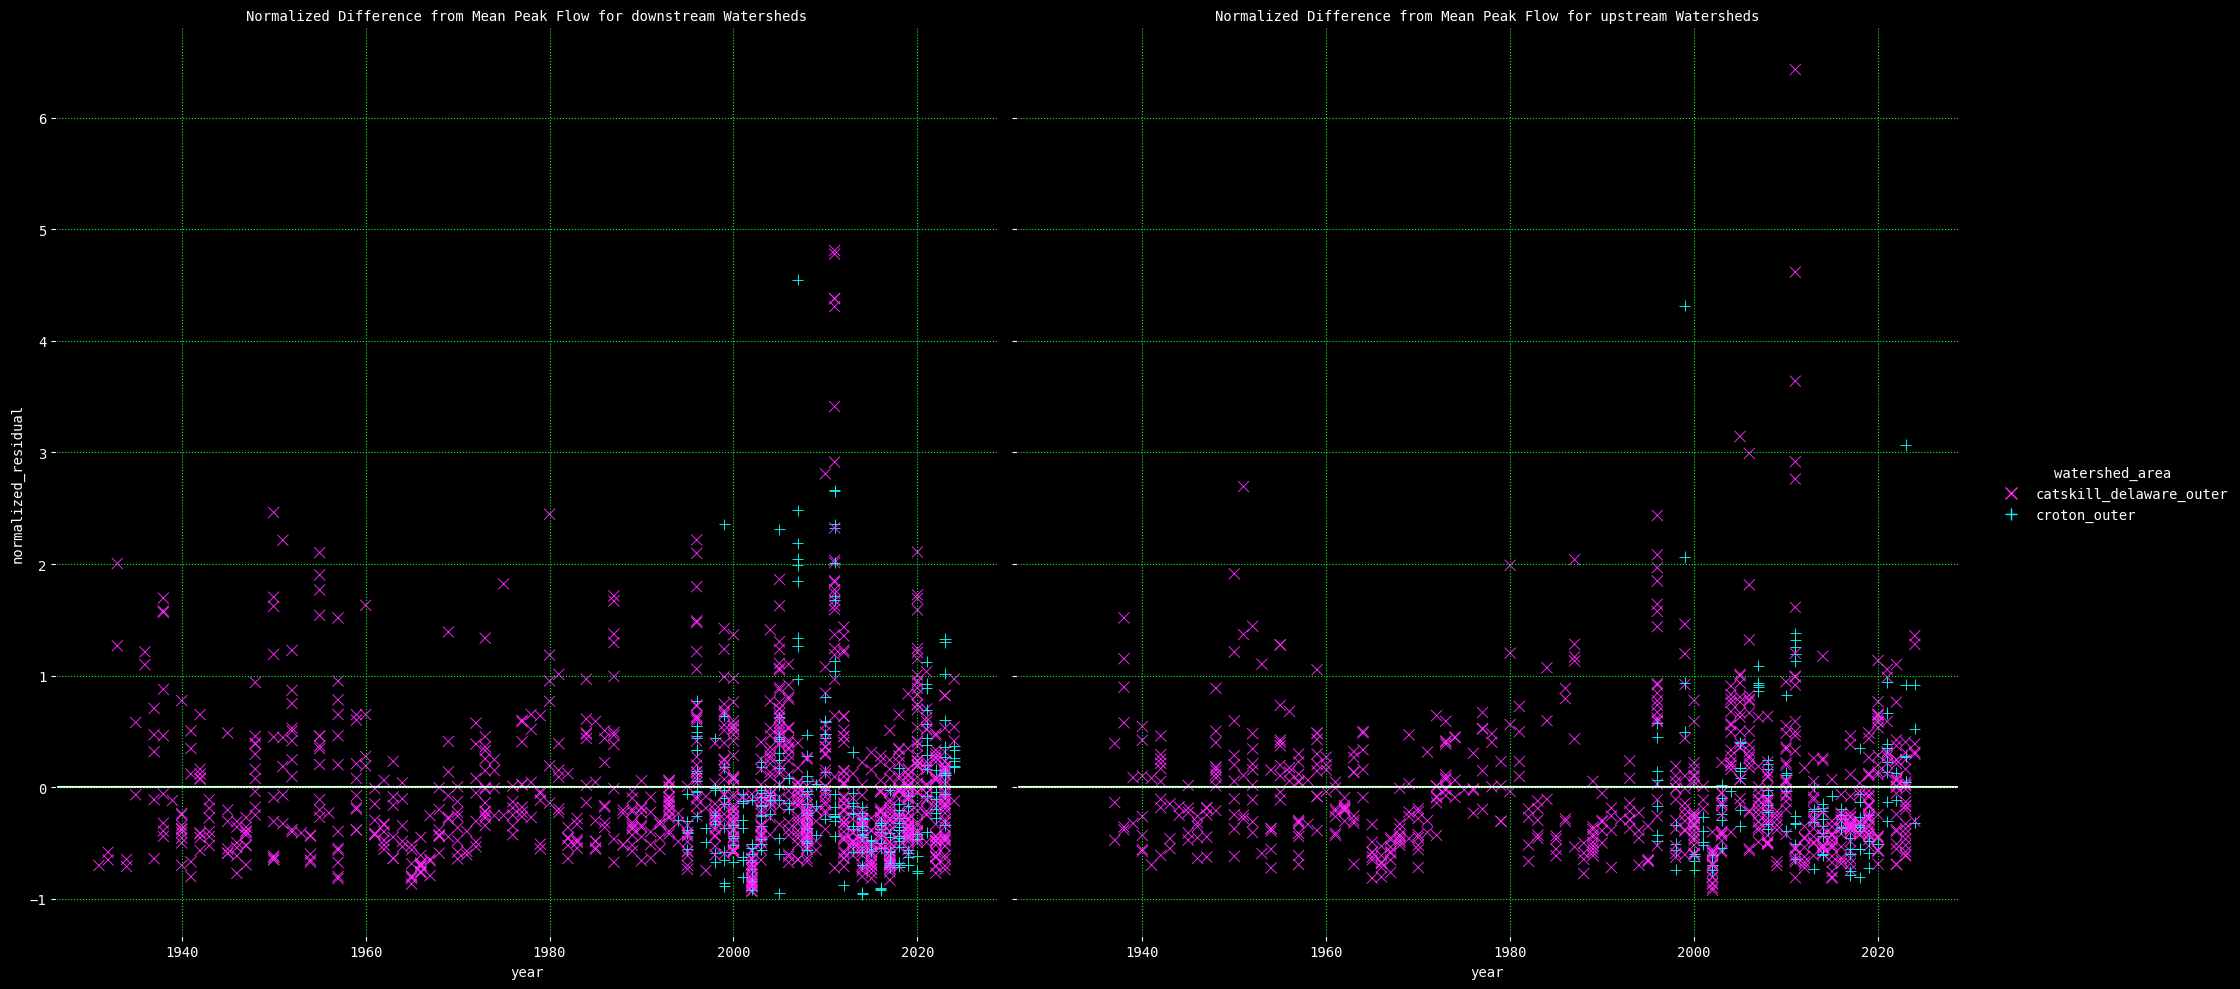

In [78]:
g = sns.relplot(data=peaks_watersheds, x="year", y="normalized_residual", col="relative_location", hue="watershed_area", style="watershed_area", markers=["x", "+"], s=64, height=10, aspect=1)
# sns.scatterplot(data=peaks_watersheds, x="year", y="normalized_residual", hue="watershed_area", style="watershed_area", markers=["x", "+"], s=64, ax=ax)
g.map(plt.axhline, y=0, color="white", zorder=1)
plt.setp(g.legend.legend_handles, markeredgewidth=1)
g.set_titles("Normalized Difference from Mean Peak Flow for {col_name} Watersheds")

In [30]:
def log_var(x):
    return np.log(x.var())
# now, find the variance in the residuals, as well as the slope of the trend
normalized_variance = peaks_df.loc[:, "normalized_residual"].groupby(level="site_no").agg(["var", log_var])
normalized_variance

,var,log_var
site_no,,
01349700,0.938433,-0.063544
01349705,0.329086,-1.111437
01349711,1.166651,0.154137
01349810,1.091759,0.087790
01349950,1.863097,0.622240
...,...,...
01434017,0.268880,-1.313489
01434021,0.154430,-1.868012
01434025,0.398993,-0.918812


In [31]:
# join in some random info about the site
# TODO: include info about watershed, eg size and impermeable surfaces
variance_site_info = normalized_variance.join(
  sites.set_index("site_no"), how="left"
).join(
  site_watershed_gdf, how="left", lsuffix="_site", rsuffix="_site_watershed"
)
variance_site_info

,var,log_var,agency_cd,station_nm,site_tp_cd,dec_lat_va,dec_long_va,coord_acy_cd,dec_coord_datum_cd,alt_va,...,barren,deciduous,evergreen,mixed_forest,shrub,grasslands,pasture,cultivated,wetlands,relative_location
site_no,,,,,,,,,,,,,,,,,,,,,
01349700,0.938433,-0.063544,USGS,EAST KILL NEAR JEWETT CENTER NY,ST,42.249167,-74.302778,S,NAD83,1451.65,...,0.000444,0.541706,0.068191,0.259565,0.000927,0.0,0.043463,0.001992,0.027283,downstream
01349705,0.329086,-1.111437,USGS,SCHOHARIE CREEK NEAR LEXINGTON NY,ST,42.236944,-74.340278,S,NAD83,1339.23,...,0.001540,0.491027,0.093967,0.275782,0.001629,0.0,0.037955,0.000709,0.029428,downstream
01349711,1.166651,0.154137,USGS,WEST KILL BELOW HUNTER BROOK NEAR SPRUCETON NY,ST,42.185056,-74.277111,1,NAD83,2038.89,...,0.000058,0.698525,0.064135,0.168883,0.000183,0.0,0.034616,0.000000,0.004906,downstream
01349810,1.091759,0.087790,USGS,WEST KILL NEAR WEST KILL NY,ST,42.230278,-74.393056,S,NAD83,1370.67,...,0.000058,0.698525,0.064135,0.168883,0.000183,0.0,0.034616,0.000000,0.004906,downstream
01349950,1.863097,0.622240,USGS,BATAVIA KILL AT RED FALLS NEAR PRATTSVILLE NY,ST,42.308333,-74.390000,S,NAD83,1268.54,...,0.000919,0.469981,0.086772,0.251850,0.001768,0.0,0.084271,0.001145,0.025705,upstream
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
01434017,0.268880,-1.313489,USGS,EAST BRANCH NEVERSINK RIVER NEAR CLARYVILLE NY,ST,41.925278,-74.540278,S,NAD83,1727.44,...,0.000037,0.694396,0.081449,0.193998,0.000543,0.0,0.006732,0.000000,0.002853,downstream
01434021,0.154430,-1.868012,USGS,W BR NEVERSINK R AT WINNISOOK L NR FROST VALLE...,ST,42.011111,-74.414444,S,NAD83,2675.00,...,0.000000,0.740195,0.125462,0.121367,0.000222,0.0,0.000000,0.000000,0.001550,downstream
01434025,0.398993,-0.918812,USGS,BISCUIT BK ABOVE PIGEON BK AT FROST VALLEY NY,ST,41.996083,-74.500222,1,NAD83,2057.25,...,0.000000,0.981433,0.002894,0.015646,0.000000,0.0,0.000000,0.000000,0.000000,downstream


<Axes: xlabel='log_var', ylabel='Count'>

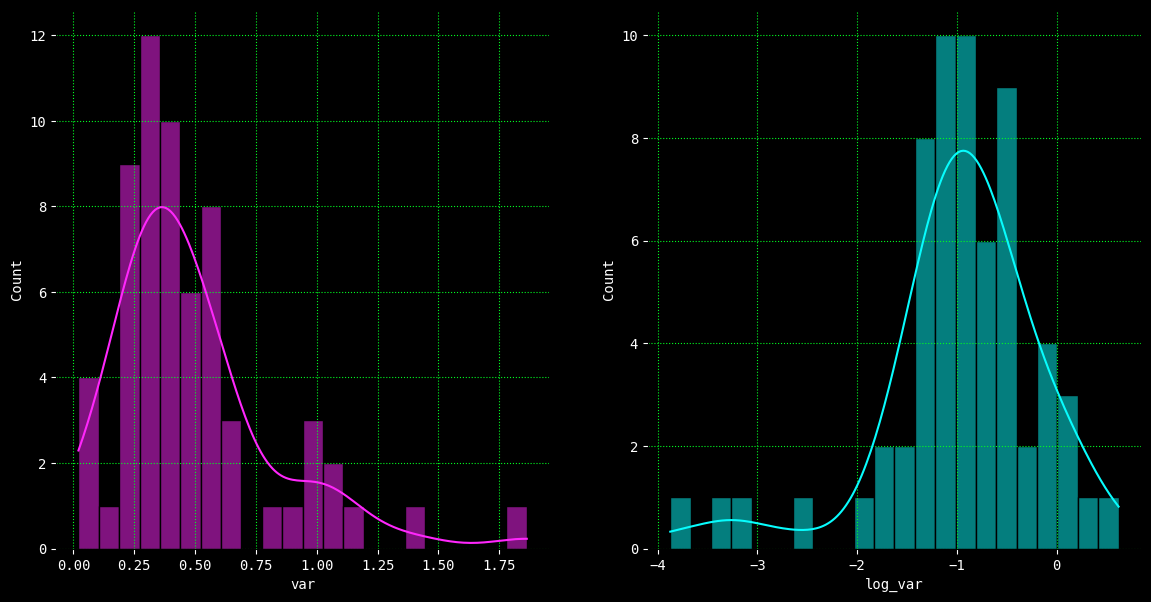

In [32]:
fig, ax = plt.subplots(1,2, figsize=(14, 7))
sns.histplot(data=normalized_variance.loc[:, "var"], bins=22, ax=ax[0], kde=True)
sns.histplot(data=normalized_variance.loc[:, "log_var"], bins=22, ax=ax[1], kde=True, color=blue)

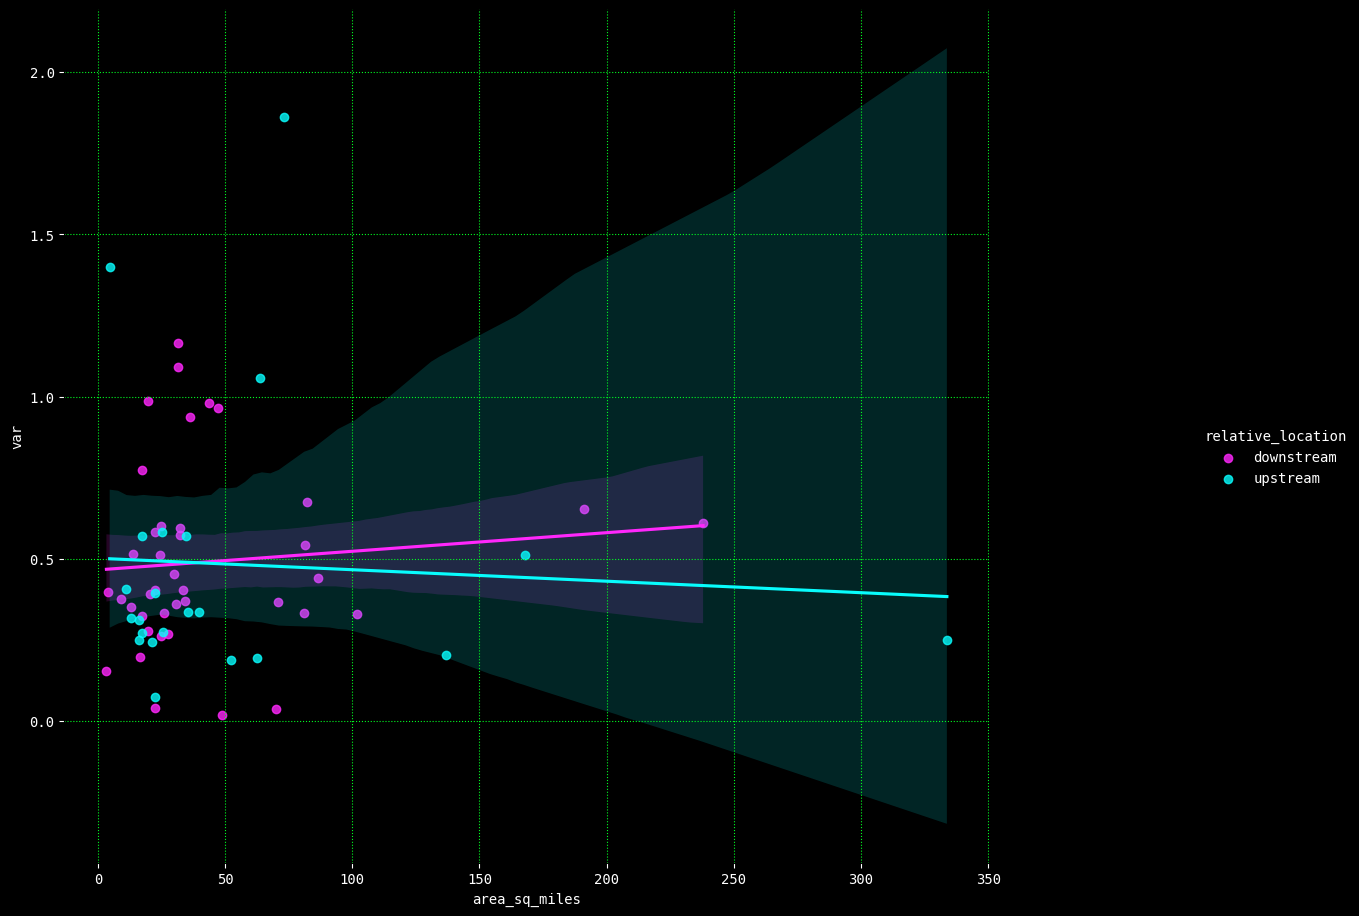

In [33]:
g = sns.lmplot(data=variance_site_info, x="area_sq_miles", y="var", hue="relative_location")
g.figure.set_size_inches(15,10)

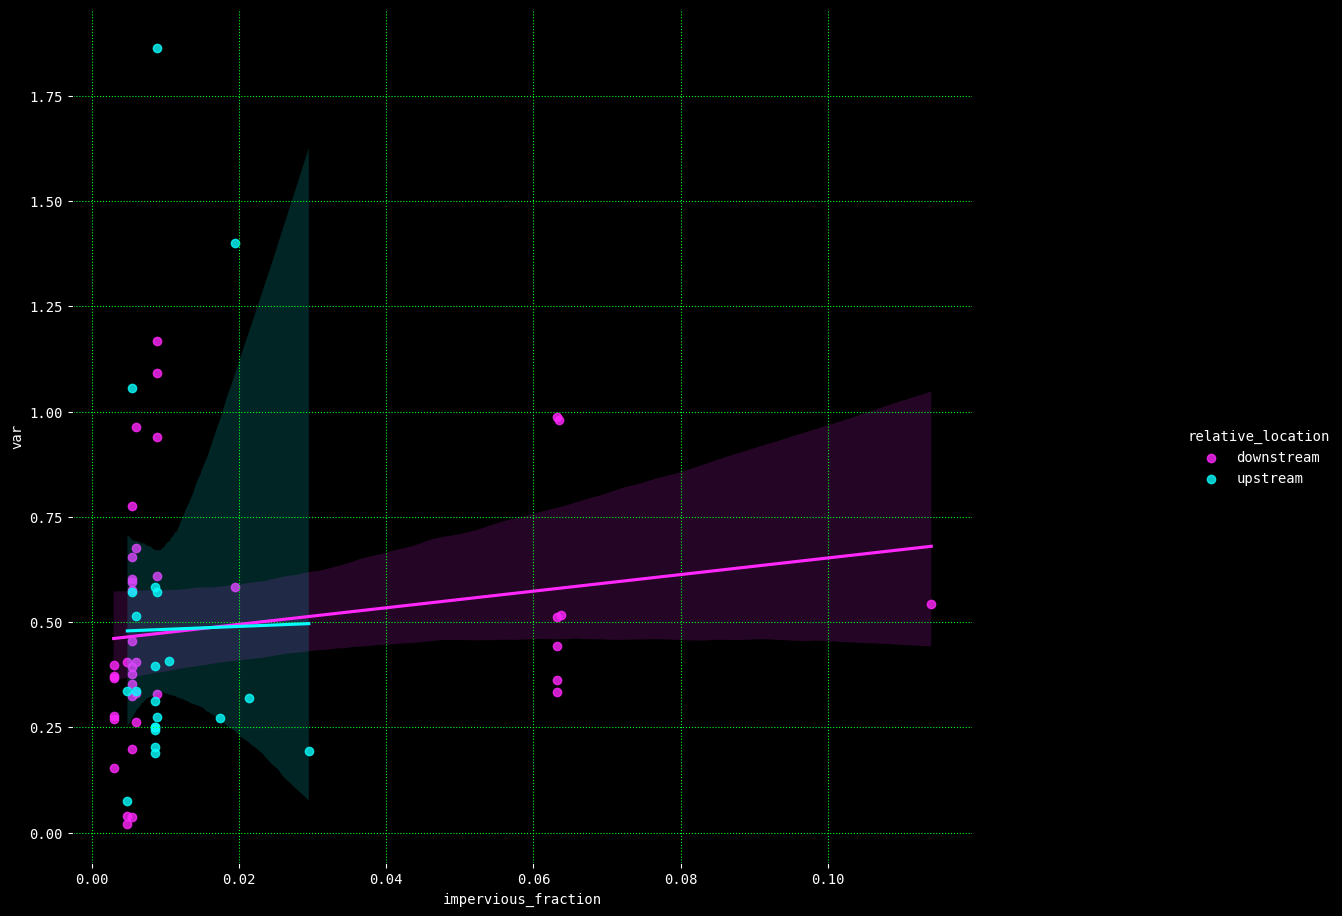

In [34]:
g = sns.lmplot(data=variance_site_info, x="impervious_fraction", y="var", hue="relative_location")
g.figure.set_size_inches(15,10)

In [35]:
anova_model = smf.ols('var ~ C(watershed_area) + C(relative_location)', data=variance_site_info).fit()
anova_table = anova.anova_lm(anova_model, typ=2)
# print the results
print(anova_table)

                        sum_sq    df         F    PR(>F)
C(watershed_area)     0.094435   1.0  0.806995  0.372662
C(relative_location)  0.001246   1.0  0.010649  0.918159
Residual              6.904200  59.0       NaN       NaN


In [36]:
ancova_model = smf.ols("var ~ C(watershed_area):C(relative_location) + impervious_fraction + cultivated + deciduous + wetlands + pasture", data=variance_site_info)
result = ancova_model.fit()
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                    var   R-squared:                       0.179
Model:                            OLS   Adj. R-squared:                  0.055
Method:                 Least Squares   F-statistic:                     1.446
Date:                Mon, 18 Aug 2025   Prob (F-statistic):              0.200
Time:                        12:51:00   Log-Likelihood:                -14.237
No. Observations:                  62   AIC:                             46.47
Df Residuals:                      53   BIC:                             65.62
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                                                         coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------

In [37]:
anova.anova_lm(result)

,df,sum_sq,mean_sq,F,PR(>F)
C(watershed_area):C(relative_location),3.0,0.108896,0.036299,0.334808,0.800206
impervious_fraction,1.0,0.007078,0.007078,0.065284,0.799321
cultivated,1.0,0.287264,0.287264,2.649628,0.109505
deciduous,1.0,0.006019,0.006019,0.055513,0.814642
wetlands,1.0,0.491398,0.491398,4.532498,0.037922
pasture,1.0,0.353091,0.353091,3.256794,0.076811
Residual,53.0,5.746080,0.108417,NaN,NaN


In [38]:
model = smf.ols("var ~ impervious_fraction", data=variance_site_info)
result = model.fit()
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                    var   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.9618
Date:                Mon, 18 Aug 2025   Prob (F-statistic):              0.331
Time:                        12:51:00   Log-Likelihood:                -19.862
No. Observations:                  62   AIC:                             43.72
Df Residuals:                      60   BIC:                             47.98
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.4587    

In [39]:
model = smf.ols("var ~ impervious_fraction + cultivated + deciduous + wetlands + pasture + area_sq_miles", data=variance_site_info)
result = model.fit()
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                    var   R-squared:                       0.084
Model:                            OLS   Adj. R-squared:                 -0.016
Method:                 Least Squares   F-statistic:                    0.8366
Date:                Mon, 18 Aug 2025   Prob (F-statistic):              0.547
Time:                        12:51:00   Log-Likelihood:                -17.648
No. Observations:                  62   AIC:                             49.30
Df Residuals:                      55   BIC:                             64.19
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.7481    

Nothing super conclusive here. There's some indication that wetlands, pasture, and impervious area could have an impact on stream flow variations, but we'll have to leave it at that for now!

## Method of Moments Analysis on each site's peaks

```
F(X) = e^(-e^(-b(X-a)))
a = mean(Q) - 0.5772/b
b = pi/(standard deviation of Q*sqrt(6))

X = a - 1/b*ln(ln(T(X)/T(X-1)))
```

This gives us a probabalistic flow or relative frequency for given flow based on the Gumbel distribution. This is from the textbook *Fundamentals of Hydrology (2nd ed)* by Tim Davie.

From this fitted distribution, we can calculate expected return period of a given flow rate or flow rate for a given return period. This is where "100-year flood" comes from.

Another option, one that seems to be the standard, would be Log-Pearson Type 3 distribution, described [here](https://streamflow.engr.oregonstate.edu/analysis/floodfreq/)

In [40]:
# first, calculate the cumulative distribution function and empirical return rate
# perhaps do a kolmogoroff-smirnoff test to check the fit of the model
peak_va_sites = peaks_df.index.get_level_values(0).unique()
for site_id in peak_va_sites:
    vals = peaks_df.loc[(site_id), "peak_va"].values
    peaks_df.loc[(site_id), "rel_freq"] = np.array([calc_relative_frequency(x, vals=vals) for x in vals])
peaks_df["peak_cumecs"] = peaks_df["peak_va"] * cubic_ft_cumec_const
peaks_df["empirical_return_period"] = 1/(1-peaks_df["rel_freq"])
empirical_maximums = peaks_df.loc[:,["peak_va", "peak_cumecs", "empirical_return_period"]].groupby(level="site_no").agg(["max", "count"])
peaks_df

agency_cd peak_tm  peak_va peak_cd  \
site_no  datetime                                                       
01349700 1951-03-31 00:00:00+00:00      USGS     NaN   6450.0       7   
         1955-10-16 00:00:00+00:00      USGS     NaN   9920.0       7   
         1960-09-12 00:00:00+00:00      USGS     NaN   7900.0     2,7   
         1965-08-14 00:00:00+00:00      USGS     NaN    860.0       2   
         1966-03-25 00:00:00+00:00      USGS     NaN   1500.0       2   
...                                      ...     ...      ...     ...   
01435000 2019-11-01 00:00:00+00:00      USGS   01:15   8530.0     NaN   
         2020-12-25 00:00:00+00:00      USGS   05:45   9100.0     NaN   
         2021-10-26 00:00:00+00:00      USGS   14:20   9170.0     NaN   
         2022-12-07 00:00:00+00:00      USGS   03:50   4000.0     NaN   
         2023-12-18 00:00:00+00:00      USGS   07:37   7020.0     NaN   

                                    gage_ht gage_ht_cd  year_last_pk  \
site_no  datetime                                                      
01349700 1951-03-31 00:00:00+00:00     8.92          3           NaN   
         1955-10-16 00:00:00+00:00    11.10          3           NaN   
         1960-09-12 00:00:00+00:00      NaN        NaN           NaN   
         1965-08-14 00:00:00+00:00     3.40          3           NaN   
         1966-03-25 00:00:00+00:00      NaN        NaN           NaN   
...                                     ...        ...           ...   
01435000 2019-11-01 00:00:00+00:00    11.48        NaN           NaN   
         2020-12-25 00:00:00+00:00    11.65          2           NaN   
         2021-10-26 00:00:00+00:00    11.68        NaN           NaN   
         2022-12-07 00:00:00+00:00     9.74        NaN           NaN   
         2023-12-18 00:00:00+00:00    11.47        NaN           NaN   

                                         ag_dt  ag_tm  ag_gage_ht  \
site_no  datetime                                                   
01349700 1951-03-31 00:00:00+00:00         NaN    NaN         NaN   
         1955-10-16 00:00:00+00:00         NaN    NaN         NaN   
         1960-09-12 00:00:00+00:00         NaN    NaN         NaN   
         1965-08-14 00:00:00+00:00         NaN    NaN         NaN   
         1966-03-25 00:00:00+00:00         NaN    NaN         NaN   
...                                        ...    ...         ...   
01435000 2019-11-01 00:00:00+00:00         NaN    NaN         NaN   
         2020-12-25 00:00:00+00:00  2020-12-25  407.0       12.34   
         2021-10-26 00:00:00+00:00         NaN    NaN         NaN   
         2022-12-07 00:00:00+00:00         NaN    NaN         NaN   
         2023-12-18 00:00:00+00:00         NaN    NaN         NaN   

                                   ag_gage_ht_cd  year     residual  \
site_no  datetime                                                     
01349700 1951-03-31 00:00:00+00:00           NaN  1951  -477.777804   
         1955-10-16 00:00:00+00:00           NaN  1955  3126.374644   
         1960-09-12 00:00:00+00:00           NaN  1960  1274.065203   
         1965-08-14 00:00:00+00:00           NaN  1965 -5598.244238   
         1966-03-25 00:00:00+00:00           NaN  1966 -4924.706126   
...                                          ...   ...          ...   
01435000 2019-11-01 00:00:00+00:00           NaN  2019   887.360279   
         2020-12-25 00:00:00+00:00             1  2020  1444.537304   
         2021-10-26 00:00:00+00:00           NaN  2021  1501.714328   
         2022-12-07 00:00:00+00:00           NaN  2022 -3681.108648   
         2023-12-18 00:00:00+00:00           NaN  2023  -673.931624   

                                    predicted_mean  normalized_residual  \
site_no  datetime                                                         
01349700 1951-03-31 00:00:00+00:00     6927.777804            -0.068966   
         1955-10-16 00:00:00+00:00     6793.625356             0.460192   
         1960-09-12 00:00:

In [41]:
moment_calcs = peaks_df.loc[:,"peak_va"].groupby(level="site_no").agg(["mean",  "std"])
moment_calcs["b"] = np.pi/(moment_calcs["std"]*np.sqrt(6))
moment_calcs["a"] = moment_calcs["mean"]-(np.float64(0.5772)/moment_calcs["b"])
moment_calcs

years_to_calc = [2, 5, 10, 25, 50, 100]
return_period_idx = pd.MultiIndex.from_product([moment_calcs.index, years_to_calc], names=["site_no", "return_period"])
return_period_df = return_period_idx.to_frame()
# this should be easy with vectorized functions but I can't figure out how!
for moment in moment_calcs.itertuples():
    for year in years_to_calc + [empirical_maximums.loc[moment.Index, ("empirical_return_period", "max")]]:
        return_period_df.loc[(moment.Index, year), "flow"] = moment.a - (1/moment.b) * np.log(np.log(year/(year-1)))

return_period_df["flow_cumecs"] = return_period_df["flow"] * cubic_ft_cumec_const
return_period_df

site_no  return_period          flow  flow_cumecs
site_no  return_period                                                    
01349700 2.0            01349700            2.0   4529.884510   128.271834
         5.0            01349700            5.0   8954.343354   253.558350
         10.0           01349700           10.0  11883.720094   336.508925
         25.0           01349700           25.0  15584.995371   441.317197
         50.0           01349700           50.0  18330.812809   519.069960
...                          ...            ...           ...          ...
01434017 34.0                NaN            NaN   6073.427470   171.980031
01434021 28.0                NaN            NaN    283.083864     8.016029
01434025 42.0                NaN            NaN   1107.609166    31.363947
01434498 34.0                NaN            NaN  10955.586327   310.227147
01435000 87.0                NaN            NaN  20328.424436   575.635929

[448 rows x 4 columns]

### Plot various characteristics at different sites

In [42]:
return_watersheds = pd.merge(return_period_df.loc[:, ["flow", "flow_cumecs"]].reset_index().set_index("site_no"), site_watershed_gdf, on="site_no").reset_index()
return_watersheds[return_watersheds["relative_location"] == "upstream"]

,site_no,return_period,flow,flow_cumecs,basin_name,area_sq_miles,BASIN,watershed_area,geometry,impervious_fraction,barren,deciduous,evergreen,mixed_forest,shrub,grasslands,pasture,cultivated,wetlands,relative_location
24,01349950,2.0,4712.197159,133.434345,Schoharie 01349950,73.186323,Schoharie,catskill_delaware_outer,"POLYGON ((-74.27005 42.36762, -74.2664 42.3739...",0.008899,0.000919,0.469981,0.086772,0.251850,0.001768,0.0,0.084271,0.001145,0.025705,upstream
25,01349950,5.0,12303.004373,348.381714,Schoharie 01349950,73.186323,Schoharie,catskill_delaware_outer,"POLYGON ((-74.27005 42.36762, -74.2664 42.3739...",0.008899,0.000919,0.469981,0.086772,0.251850,0.001768,0.0,0.084271,0.001145,0.025705,upstream
26,01349950,10.0,17328.779248,490.695576,Schoharie 01349950,73.186323,Schoharie,catskill_delaware_outer,"POLYGON ((-74.27005 42.36762, -74.2664 42.3739...",0.008899,0.000919,0.469981,0.086772,0.251850,0.001768,0.0,0.084271,0.001145,0.025705,upstream
27,01349950,25.0,23678.859124,670.509518,Schoharie 01349950,73.186323,Schoharie,catskill_delaware_outer,"POLYGON ((-74.27005 42.36762, -74.2664 42.3739...",0.008899,0.000919,0.469981,0.086772,0.251850,0.001768,0.0,0.084271,0.001145,0.025705,upstream
28,01349950,50.0,28389.711129,803.905772,Schoharie 01349950,73.186323,Schoharie,catskill_delaware_outer,"POLYGON ((-74.27005 42.36762, -74.2664 42.3739...",0.008899,0.000919,0.469981,0.086772,0.251850,0.001768,0.0,0.084271,0.001145,0.025705,upstream
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430,01422500,67.0,5164.824775,146.251310,Cannonsville 01422500,52.188385,Cannonsville,catskill_delaware_outer,"POLYGON ((-74.82004 42.23044, -74.82081 42.228...",0.008604,0.000062,0.676159,0.007586,0.035505,0.000222,0.0,0.209974,0.001190,0.006752,upstream
431,01422747,23.0,4416.366793,125.057375,Cannonsville 01422747,25.040395,Cannonsville,catskill_delaware_outer,"POLYGON ((-75.12762 42.17217, -75.12447 42.177...",0.008604,0.000092,0.613600,0.004415,0.033527,0.000170,0.0,0.272386,0.000554,0.007482,upstream
432,01422779,8.0,1915.484171,54.240382,Cannonsville 01422779,22.440120,Cannonsville,catskill_delaware_outer,"POLYGON ((-75.13669 42.16885, -75.13237 42.174...",0.008604,0.000143,0.575338,0.026639,0.039774,0.000107,0.0,0.267247,0.005489,0.014008,upstream
433,01423000,75.0,25288.324878,716.084438,Cannonsville 01423000,333.765526,Cannonsville,catskill_delaware_outer,"POLYGON ((-75.14564 42.15658, -75.14744 42.159...",0.008604,0.000499,0.585335,0.011424,0.047180,0.000155,0.0,0.260505,0.011246,0.013259,upstream


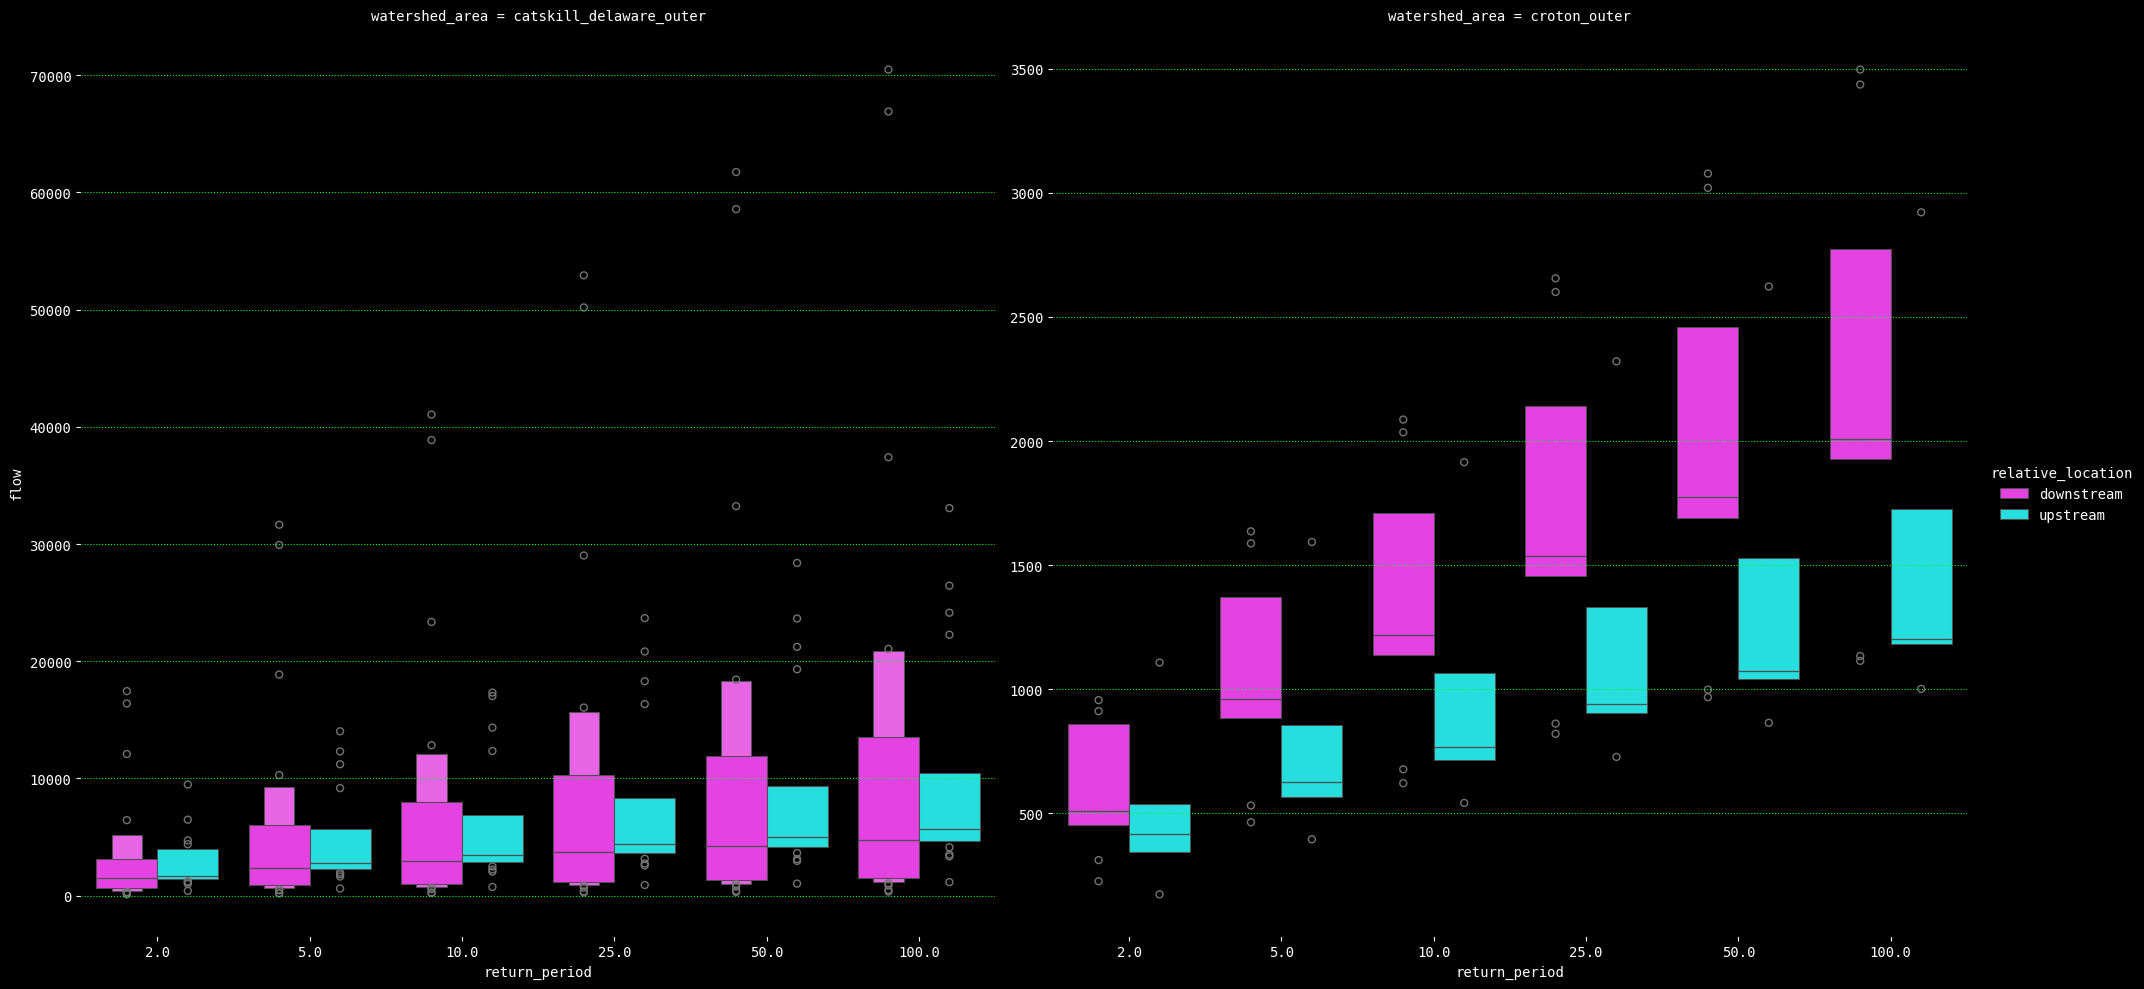

In [43]:
sns.catplot(data=return_watersheds[return_watersheds["return_period"].isin([2, 5, 10, 25, 50, 100])], x="return_period", y="flow", col="watershed_area", kind="boxen", hue="relative_location", sharex=True, sharey=False, height=10, aspect=1)
# g = sns.barplot(data=return_watersheds[return_watersheds["return_period"].isin([2, 5, 10, 25, 50, 100])], x="return_period", y="flow", hue="watershed_area")
